In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv('../data/superstore.csv')

# Create customer-level features: Frequency and Monetary
customer_features = df.groupby('Customer ID').agg(
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
).reset_index()

customer_features.head()

,Customer ID,Frequency,Monetary
0,AA-10315,5,5563.560
1,AA-10375,9,1056.390
2,AA-10480,4,1790.512
3,AA-10645,6,5086.935
4,AB-10015,3,886.156


In [2]:
# Standardize features (K-Means is sensitive to scale)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(customer_features[['Frequency', 'Monetary']])

print("Scaled features shape:", features_scaled.shape)
print(features_scaled[:5])

Scaled features shape: (793, 2)
[[-0.47812351  1.03538325]
 [ 1.1066286  -0.6855571 ]
 [-0.87431153 -0.40525257]
 [-0.08193548  0.85339695]
 [-1.27049956 -0.75055632]]


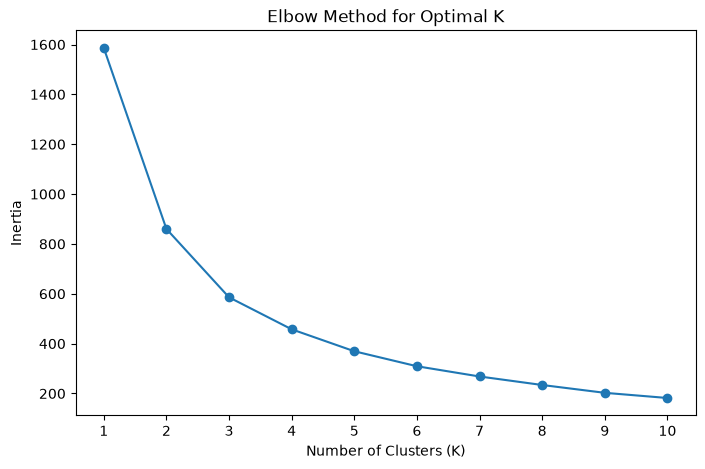

In [3]:
# Elbow Method to find optimal number of clusters
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

In [4]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_features['Cluster'] = kmeans_final.fit_predict(features_scaled)

customer_features.head(10)

,Customer ID,Frequency,Monetary,Cluster
0,AA-10315,5,5563.560,3
1,AA-10375,9,1056.390,0
2,AA-10480,4,1790.512,1
3,AA-10645,6,5086.935,3
4,AB-10015,3,886.156,1
5,AB-10060,8,7755.620,2
6,AB-10105,10,14473.571,2
7,AB-10150,5,966.710,1
8,AB-10165,8,1113.838,3
9,AB-10255,9,914.532,0


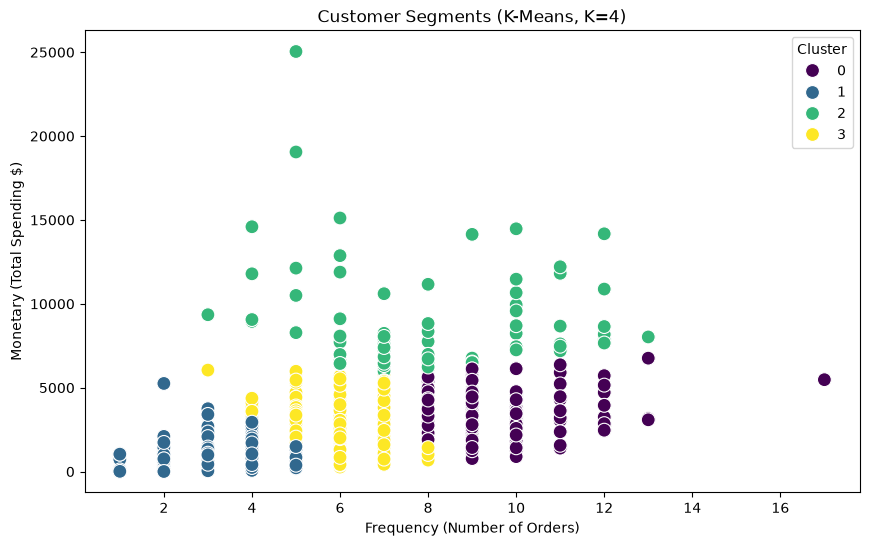

,Num_Customers,Avg_Frequency,Avg_Monetary
Cluster,,,
0,175,9.39,3413.18
1,248,3.57,1005.89
2,70,8.01,9184.97
3,300,6.11,2572.74


In [5]:
# Visualize the 4 customer segments
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_features, x='Frequency', y='Monetary', 
                 hue='Cluster', palette='viridis', s=100)
plt.title('Customer Segments (K-Means, K=4)')
plt.xlabel('Frequency (Number of Orders)')
plt.ylabel('Monetary (Total Spending $)')
plt.show()

# Average Frequency and Monetary per cluster
cluster_summary = customer_features.groupby('Cluster').agg(
    Num_Customers=('Customer ID', 'count'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2)

cluster_summary

In [6]:
# Revenue contribution by cluster
total_revenue = customer_features['Monetary'].sum()
cluster_summary['Total_Revenue'] = customer_features.groupby('Cluster')['Monetary'].sum()
cluster_summary['Revenue_Percentage'] = (cluster_summary['Total_Revenue'] / total_revenue * 100).round(2)

cluster_summary

,Num_Customers,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_Percentage
Cluster,,,,,
0,175,9.39,3413.18,597307.3145,26.41
1,248,3.57,1005.89,249459.4909,11.03
2,70,8.01,9184.97,642948.2360,28.43
3,300,6.11,2572.74,771821.7413,34.13
